# Image Segmentation

Author: Hasith Wijesuriya 

Email: hasitha.wijesuriya@pnnl.gov

## Why Image Segmentation?

Image segmentation is a fundamental task in computer vision that involves partitioning an image into meaningful regions or segments. It is crucial for various applications, including object recognition, medical imaging, autonomous driving, and scene understanding. By segmenting an image, we can identify and analyze specific objects or areas of interest, which can lead to better decision-making and improved performance in downstream tasks.

### Why is it important in soil science?

In soil science, image segmentation plays a vital role in analyzing soil properties and understanding soil structure. It allows researchers to identify and quantify different soil components, such as organic matter, minerals, and pore spaces. This information is essential for studying soil health, fertility, and water retention capabilities. Additionally, image segmentation can help in monitoring soil erosion, assessing land degradation, and optimizing agricultural practices by providing insights into soil composition and structure.

## Types of Image Segmentation

There are several types of image segmentation techniques, each with its own advantages and applications. Some common types include:

1. **Thresholding**: This technique involves separating pixels based on their intensity values. It is simple and effective for images with distinct foreground and background regions.
2. **Edge-based Segmentation**: This method detects edges in an image to define segment boundaries. It is useful for images with clear edges and can be implemented using techniques like Canny edge detection.
3. **Region-based Segmentation**: This approach groups pixels into regions based on similarity criteria, such as color or texture. It can be implemented using methods like region growing or watershed segmentation.
4. **Clustering-based Segmentation**: This technique uses clustering algorithms, such as K-means or mean shift, to group pixels into clusters based on their features. It is effective for images with complex patterns and textures.
5. **Deep Learning-based Segmentation**: This method utilizes convolutional neural networks (CNNs) to learn features and perform segmentation. It has shown significant improvements in accuracy and is widely used in various applications, including medical imaging and autonomous driving.

## Challenges in Image Segmentation

Despite its importance, image segmentation faces several challenges, including:
1. **Variability in Image Quality**: Images can vary in quality due to factors like contrast, noise, and resolution, which can affect segmentation accuracy.
2. **Complexity of Scenes**: Real-world images often contain complex scenes with multiple objects and varying backgrounds, making segmentation more difficult.
3. **Computational Complexity**: Some segmentation techniques, especially deep learning-based methods, can be computationally intensive and require significant resources for training and inference.
4. **Lack of Annotated Data**: For supervised learning-based segmentation methods, obtaining annotated data can be time-consuming and expensive, especially in specialized domains like soil science.
5. **Generalization**: Segmentation models may struggle to generalize well to new images or different domains, leading to reduced performance when applied to unseen data.



## Thresholding Methods

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import os
import sys
from skimage.filters import threshold_otsu, threshold_niblack, threshold_sauvola
from scipy.ndimage import correlate
sys.path.append('./')
import HMRF_EM as hmrf



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

# Load the 8-bit grayscale image
img = mpimg.imread("./Images/Bean Bucket 8bit image0000.tif")

def update_threshold(thresh_val):
    '''
    Update the binary image based on the threshold value and display both original and binary images.
    Parameters:
    thresh_val (int): The threshold value to convert the grayscale image to binary.
    '''
    binary_img = img > thresh_val
    plt.figure(figsize=(12, 6))
    
    
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f'Binary Image (Threshold: {thresh_val})')
    plt.axis('off')
    plt.show()


interact(update_threshold, thresh_val=IntSlider(min=0, max=255, step=1, value=127));

interactive(children=(IntSlider(value=127, description='thresh_val', max=255), Output()), _dom_classes=('widge…

### Otsu's method
Otsu's method is a global thresholding technique that automatically determines the optimal threshold value by maximizing the between-class variance. It is effective for images with bimodal histograms, where the foreground and background are well separated.

$\sigma^2_\omega (t) = \omega_1 (t) \sigma^2_1 (t) + \omega_2 (t) \sigma^2_2 (t)$

Where:
- $\omega_1 (t)$ and $\omega_2 (t)$ are the probabilities of the two classes separated by the threshold t.
- $\sigma^2_1 (t)$ and $\sigma^2_2 (t)$ are the variances of the two classes.



### Niblack's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood around the pixel. It is effective for images with varying contrast.

$T(x,y) = m(x,y) + k \cdot s(x,y)$

Where:
- $T(x,y)$ is the threshold for the pixel at coordinates (x, y).
- $m(x,y)$ is the mean of the local neighborhood around the pixel.
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel.
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold.


### Sauvola's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood, similar to Niblack's method, but includes a parameter to control the influence of the standard deviation. It is effective for images with varying contrast and noise.

$T(x,y) = m(x,y) \cdot \left(1 + k \cdot \left(\frac{s(x,y)}{R} - 1\right)\right)$

Where:
- $T(x,y)$ is the threshold for the pixel at coordinates (x, y).
- $m(x,y)$ is the mean of the local neighborhood around the pixel.
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel.
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold.
- $R$ is the dynamic range of the standard deviation (typically set to 128 for 8-bit images).


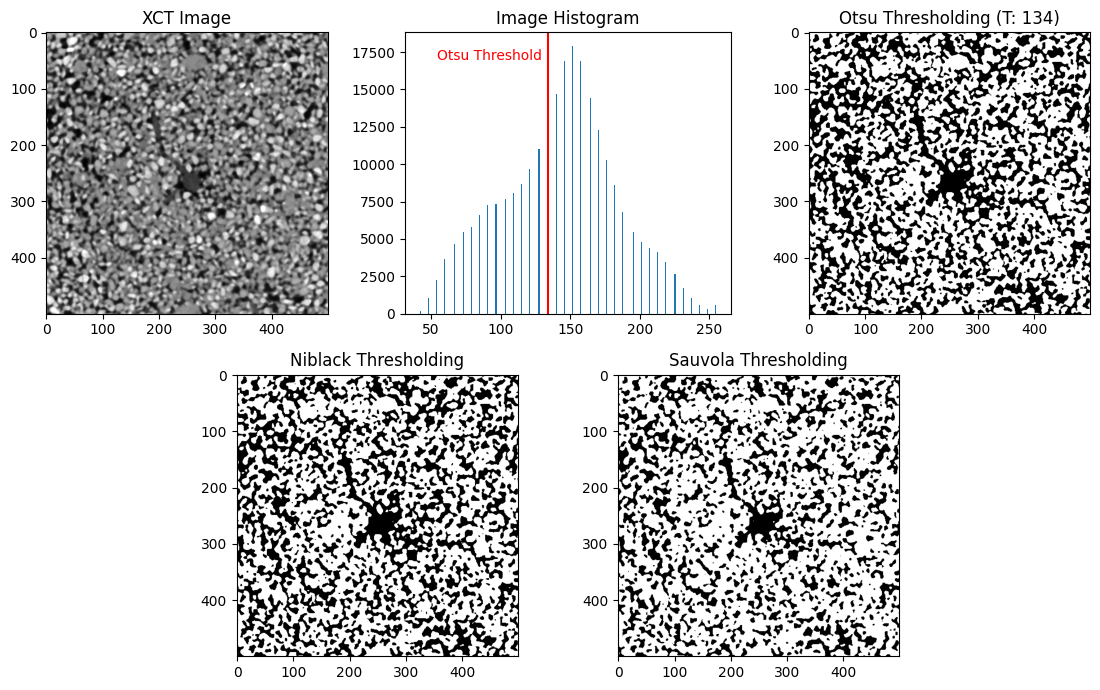

In [ ]:
# Load the 8-bit grayscale image
img = mpimg.imread("./Images/Bean Bucket 8bit image0000.tif")

# Apply different thresholding methods #
# Otsu's method, Niblack's method, and Sauvola's method are applied to the image to compute the respective thresholds.
thresh_otsu = threshold_otsu(img)
thresh_niblack = threshold_niblack(img, window_size=301, k=0.2)
thresh_sauvola = threshold_sauvola(img, window_size=301)

# The resulting binary images are created by comparing the original image to the computed thresholds, 
# resulting in binary images where pixels above the threshold are set to True (or 1) and those below are set to False (or 0).
binary_niblack = img > thresh_niblack
binary_otsu = img > thresh_otsu
binary_sauvola = img > thresh_sauvola


# Visualization of the original image, histogram, and the results of the three thresholding methods.
fig = plt.figure(figsize=(15, 7), tight_layout=True)
spec = gridspec.GridSpec(ncols=8, nrows=2, figure=fig)

positions = [
    (0, slice(1, 3)), (0, slice(3, 5)), (0, slice(5, 7)), # Row 0
    (1, slice(2, 4)), (1, slice(4, 6))                   # Row 1 (centered)
]

ax = [fig.add_subplot(spec[row, col]) for row, col in positions]


ax[0].imshow(img, cmap="gray")
ax[0].set_title("XCT Image")
ax[1].hist(img.ravel(), bins=255)
ax[1].axvline(thresh_otsu, color='r')
ax[1].text(thresh_otsu -80, ax[1].get_ylim()[1] * 0.9, 'Otsu Threshold', color='r')
ax[1].set_title("Image Histogram")
ax[2].imshow(binary_otsu, cmap="gray")
ax[2].set_title(f"Otsu Thresholding (T: {thresh_otsu})")
ax[3].imshow(binary_niblack, cmap="gray")
ax[3].set_title("Niblack Thresholding")
ax[4].imshow(binary_sauvola, cmap="gray")
ax[4].set_title("Sauvola Thresholding")

plt.subplots_adjust()
plt.show()

## HMRF-EM - Hidden Markov Random Fields with Expectation Maximization algorithm

Hidden Markov Random Fields (HMRF) is a probabilistic model used for image segmentation. It combines the concepts of Markov Random Fields (MRF) and Hidden Markov Models (HMM) to model the spatial dependencies between pixels and the underlying class labels. HMRF can effectively capture the spatial context of an image, making it suitable for segmenting complex scenes with varying textures and patterns.





In [7]:
def simple_binary_algorithm(data, thresh, num_dims):
    """
        Only useful for binary case
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_dims: number of dimension
        thresh: threshold 
        Output:
        ------------------------------------------------------
        label: initial labelled 
        mu: update centroid of each cluster
        sigma: update variance of each cluster
    """
    binary_clusters = 2
    mu = np.zeros((binary_clusters, num_dims))
    sigma  = np.zeros((binary_clusters, num_dims, num_dims))
    
    mu[0] = np.mean(data[data<=thresh], axis=0)
    mu[1] = np.mean(data[data>thresh], axis=0)
    sigma[0] = np.cov(data[data<=thresh].T)
    sigma[1] = np.cov(data[data>thresh].T)
    label = data>thresh
    
    return label, mu, sigma

def otsu_binary_algorithm(data, num_dims):
    """
        Only useful for binary case
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_dims: number of dimension
        Output:
        ------------------------------------------------------
        label: initial labelled 
        mu: update centroid of each cluster
        sigma: update variance of each cluster
    """
    otsu_clusters = 2
    thresh = threshold_otsu(data)
    mu = np.zeros((otsu_clusters, num_dims))
    sigma  = np.zeros((otsu_clusters, num_dims, num_dims))
    
    mu[0] = np.mean(data[data<=thresh], axis=0)
    mu[1] = np.mean(data[data>thresh], axis=0)
    sigma[0] = np.cov(data[data<=thresh].T)
    sigma[1] = np.cov(data[data>thresh].T)
    label = data>thresh
    
    return label, mu, sigma

def kmeans_initial_guess(data, num_samples, num_clusters):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        Output:
        ------------------------------------------------------
        mu: numpy array, randomly pick num_clusters value from data as
            initial guess
    """
    mu = data[np.random.choice(num_samples, num_clusters, False),:]
    return mu

def kmeans_get_label(data, num_samples, num_clusters, mu):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        mu: numpy array, centroid of each cluster
        Output:
        ------------------------------------------------------
        label: set all dataset points (pixels) to the best cluster according
            to minimal distance from centroid of each cluster
    """
    dist = np.zeros((num_samples, num_clusters))
    for k in range(num_clusters):
        dist[:,k] = np.linalg.norm(data - mu[k], axis=1)

    label = np.argmin(dist, axis=1)
    return label

def kmeans_get_means(data, num_dims, num_clusters, label):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_dims: number of dimension
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        label: label for dataset points (pixels) to the best cluster according
            to minimal distance from centroid of each cluster
        Output:
        ------------------------------------------------------
        mu: update centroid of each cluster
        sigma: update variance of each cluster
    """
    mu = np.zeros((num_clusters, num_dims))
    sigma  = np.zeros((num_clusters, num_dims, num_dims))
    for k in range(num_clusters):
        idx_list = np.where(label == k)[0]
        if(len(idx_list) == 0):
            mu[k] = data[np.random.randint(len(data)), :]
            sigma[k] = np.eye(num_dims)
        else:
            mu[k] = np.mean(data[idx_list], axis = 0)
            sigma[k] = np.cov(data[idx_list].T) # Remember to check this
    return mu, sigma

def kmeans_calc_loss(data, num_samples, num_clusters, mu, label):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        label: label for dataset points (pixels) to the best cluster according
            to minimal distance from centroid of each cluster
        mu: updated centroid of each cluster
        Output:
        ------------------------------------------------------
        return loss to determine convergence criterion
    """
    loss = 0
    for k in range(num_clusters):
        idx_list = np.where(label == k)[0]
        loss += np.sum(np.linalg.norm(data[idx_list]-mu[k], axis=1))
    return loss

def k_means_algorithm(data, num_samples, num_clusters, num_dims, verbose=False):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        num_dims: number of dimension of data, always 1 for pixels or voxels
        Output:
        ------------------------------------------------------
        labels: a list contains all segementation label from each iteration
        losses: a list contains all loss from each iteration
        mu: a list contains centroid of each cluster from each iteration
        sigma: a list contains variance of each cluster from each iteration
    """
    losses = []
    iter_cnt = 0
    epsilon = 1e-4
    max_iters = 100
    update = 2*epsilon

    #initial guess
    mus = [kmeans_initial_guess(data, num_samples, num_clusters)]
    sigmas = [np.eye(num_dims)*num_clusters]

    while (update > epsilon) and (iter_cnt < max_iters):
        iter_cnt += 1
        # Assign labels to each datapoint based on cnetroid
        label = kmeans_get_label(data, num_samples, num_clusters, mus[-1])

        # Assign centroid based on labels
        mu, sigma = kmeans_get_means(data, num_dims, num_clusters, label)
        mus.append(mu)
        sigmas.append(sigma)
        
        # Calculate loss
        losses.append(kmeans_calc_loss(data, num_samples, num_clusters, mus[-1], label))

        # Check convergence
        if iter_cnt >= 2:
            update = np.abs(losses[-1]-losses[-2])

        # Logging
        if verbose:
            print('iteration {}, update {}'.format(iter_cnt, update))
    if verbose:
        print('mu = {}, losses = {}'.format(mus[-1].flatten(), losses))

    return label, mus[-1], sigmas[-1], losses[-1]

def gaussian_U(data, mu, sigma, w):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        mu: centroid of each cluster
        sigma: variance of each cluster
        w: weight ratio between void and particle
        Output:
        ------------------------------------------------------
        return gaussian energy on each pixels
    """
    return 0.5*np.einsum('i,ij,ji->i',w,data-mu,np.linalg.inv(sigma)@(data-mu).T)+0.5*np.log(np.linalg.det(sigma)/w)

def clique_U(label, c, img_size):
    """
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        label: hidden configuration corresponds to cluster labels
        c: a particular cluster (i.e. 0 for background, 1 for forground)
        Output:
        ------------------------------------------------------
        return clique potential energy on each pixel
    """
    return np.array([clique_potential(i, label.reshape(img_size), c) for i in np.arange(len(label))])

def clique_U2(label, c, img_size):
    temp = label.reshape(img_size)
    tag1 = temp == c
    tag2 = temp != c
    constraints = np.zeros(img_size)
    constraints[tag1] = 0.
    constraints[tag2] = 0.5
    kernel = np.array([[[0.,0.,0.],[0.,0.,0.],[0.,0.,0.]],[[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]],[[0.,0.,0.],[0.,0.,0.],[0.,0.,0.]]])
    #kernel = np.array([[[1.,1.,1.],[1.,1.,1.],[1.,1.,1.]],[[1.,1.,1.],[1.,0.,1.],[1.,1.,1.]],[[1.,1.,1.],[1.,1.,1.],[1.,1.,1.]]])
    return correlate(constraints, kernel, mode='nearest').flatten()

# find a way to speed up this step
def clique_potential(idx, label, c):
    """
        This put spatial constraints on pixel, pixels are more likely to have
        same labels as their surrounding pixels.
        Input:
        ------------------------------------------------------
        idx: index of pixel of interest
        label: hidden configuration corresponds to cluster labels
        c: a particular cluster (i.e. 0 for background, 1 for forground)
        Output:
        ------------------------------------------------------
        return clique potential energy on that pixel
    """
    m, n, l = label.shape
    i = idx // (n*l)
    j = idx % (n*l) // l
    k = idx % (n*l) % l
    u = 0
    if i >= 1:
        u += (c != label[i-1, j, k])/2.
    if i < m-1:
        u += (c != label[i+1, j, k])/2.
    if j >= 1:
        u += (c != label[i, j-1, k])/2.
    if j < n-1:
        u += (c != label[i, j+1, k])/2.
    if k >= 1:
        u += (c != label[i, j, k-1])/2.
    if k < l-1:
        u += (c != label[i, j, k+1])/2.
    return u

def EM_initial_guess(data, num_samples, num_clusters, num_dims):
    """
        run this for multiple time, make sure good initialization
        EM alogirthm is very sensitive to initialization
        use K-means to determine initial means and variances
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        num_dims: number of dimension of data, always 1 for pixels or voxels
        Output:
        ------------------------------------------------------
        label: final segementation label from each iteration
        mu: final centroid of each cluster from each iteration
        sigma: final variance of each cluster from each iteration
    """
    #label, mu, sigma = otsu_binary_algorithm(data, num_dims)
    #label, mu, sigma = simple_binary_algorithm(data, 30, num_dims)
    #label, mu, sigma = otsu_binary_algorithm(data, num_dims)
    label, mu, sigma, loss = k_means_algorithm(data, num_samples, num_clusters, num_dims, verbose=False)
    return label, mu, sigma

def EM_E_step(num_clusters, num_samples, data, label, mu, sigma, beta, img_size, w):
    """
        Main goal: compute posterior of each cluster
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        label: hidden label configuration
        mu: means for each cluster in finite mixture model
        sigma: variance for each cluster in finite mixture model
        beta: ratio between Gaussian energy and clique potential energy
        img_size: image size, used to reconstruct spatial relationship
        Output:
        ------------------------------------------------------
        Uarg: cluster label corresponds to minimal energy for each pixel
        Umin: minimum energy of current configuration
        Q: posterior corresponds to each cluster
    """
    U1 = np.zeros((num_samples, num_clusters)) # Gaussian Energy
    U2 = np.zeros((num_samples, num_clusters)) # clique potential Energy

    for k in range(num_clusters):
        U1[:,k] = gaussian_U(data, mu[k], sigma[k], w)
        U2[:,k] = clique_U2(label, k, img_size)
        #U2[:,k] = clique_U(label, k, img_size)

    U = U1 + U2*beta
    #for i in np.arange(num_clusters):
    #    print("sum of U1 {}, sum of U2 {}, raio = {}".format(np.mean(U1[:,i]), np.mean(U2[:,i]), np.sum(U1[:,i])/np.sum(U2[:,i])/10 ) )
        #print('ratio between U2 and U1+U2 is {}'.format(beta*np.sum(U2[:i])/np.sum(U[:i])))
    Umin = np.min(U, axis = 1)
    Uarg = np.argmin(U, axis = 1)
    Uenergy = np.sum(Umin)

    # Consier Q2 as prior
    Q1 = np.zeros((num_samples, num_clusters)) # Gaussian probability
    Q2 = np.zeros((num_samples, num_clusters)) # clique potential probability

    for k in range(num_clusters):
        Q1[:,k] = (2*np.pi)**(-data.shape[1]/2.) * np.exp(-U1[:,k]/10) # need to be tuned because each data has different intensity distribution
        Q2[:,k] = np.exp(-U2[:,k]*beta)
    #Q1 = (Q1.T / np.sum(Q1, axis = 1)).T
    #Q2 = (Q2.T / np.sum(Q2, axis = 1)).T

    Q = Q1 * Q2
    Q = (Q.T / np.sum(Q, axis = 1)).T
    return Uarg, Uenergy, Q

def EM_M_step (num_clusters, num_dims, num_samples, Q, data, w):
    """
        Main goal: update parameters
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_dims: number of dimension
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        Q: posterior corresponds to each cluster
        w: weight ratio between void and particle
        Output:
        ------------------------------------------------------
        mu: updated mean
        sigma: updated variance
    """
    # M Step
    ## calculate the new mean and covariance for each gaussian by
    ## utilizing the new responsibilities
    mu      = np.zeros((num_clusters, num_dims))
    sigma   = np.zeros((num_clusters, num_dims, num_dims))

    ## The number of datapoints belonging to each gaussian
    num_samples_per_cluster = np.sum(Q, axis=0)
    weighted_sum = np.einsum('i,ij->j',w,Q)

    for k in range(num_clusters):
        ## means
        #mu[k] = 1./weighted_sum[k] * np.sum(w*Q[:,k]*data.T, axis = 1).T
        mu[k] = 1./weighted_sum[k] * np.einsum('i,i,ij -> j', w, Q[:,k], data)
        centered_data = np.matrix(data-mu[k])
        epsilon = 1e-6
        ## covariances
        #sigma[k] = np.array(1./num_samples_per_cluster[k]*np.dot(np.multiply(centered_data.T, w*Q[:,k]), centered_data))
        sigma[k] = (1./num_samples_per_cluster[k] * np.multiply(centered_data.T, w*Q[:,k])@centered_data) + np.eye(num_dims)*epsilon

    return mu, sigma

def EM_calc (num_dims, num_samples, num_clusters, data, img_size, void_weight=1., beta = 1., verbose=False):
    """
        This is an almost antomotic method except one might need to select void_weight;
        void_weight could be meaningfully interpreted as sample density;
        Input:
        ------------------------------------------------------
        data: numpy array, flattened input image
        num_dims: number of dimension
        num_samples: number of pixels in image
        num_clusters: number of clusters (i.e. 2 in binary segementation)
        Q: posterior corresponds to each cluster
        void_weight: weight ratio between void and particle
        Output:
        ------------------------------------------------------
        label: hidden configuration
        energy_sum: energy_sum, used to determine convergence
        mu: updated mean
        sigma: updated variance
    """
    energy_sums     = []
    iter_cnt        = 0
    epsilon         = 1
    max_iters       = 30
    update          = 2*epsilon
    #beta            = 1.
    w               = np.ones(len(data))

    # initial guess
    label, mu, sigma = EM_initial_guess(data, num_samples, num_clusters, num_dims)
    label = label.astype(np.bool)
    mus    = [mu]
    sigmas = [sigma]

    while (update > epsilon) and (iter_cnt < max_iters):
        iter_cnt += 1

        # E - Step
        label, Uenergy, Q = EM_E_step(num_clusters, num_samples, data, label, mu, sigma, beta, img_size, w)
        label = label.astype(np.bool)
        energy_sums.append(Uenergy)

        # M - Step
        mu, sigma = EM_M_step(num_clusters, num_dims, num_samples, Q, data, w)

        mus.append(mu)
        sigmas.append(sigma)


        # check convergence
        if iter_cnt >= 2 :
            update = np.abs(energy_sums[-1] - energy_sums[-2])

        # logging
        if verbose:
            print("iteration {}, update {}, mean {}".format(iter_cnt, update, mu.flatten()))

        w = np.ones(len(data))
        # label == np.argmin(mu) corresponds to void
        w[label == np.argmin(mu)] = void_weight

    print('require {} steps to finish, mu = {}'.format(iter_cnt, mus[-1].flatten()))
    energy = energy_sums[-1]
    mu = mus[-1]
    sigma = sigmas[-1]
    label = label != np.argmin(mu)
    #label = label == np.argmax(mu)
    return label, energy_sums, {'mu': mu, 'sigma': sigma}


/var/folders/7c/l9yy22cj15l8mlx3nl1h5w_h0000gn/T/ipykernel_20353/2218492019.py:361: RuntimeWarning: divide by zero encountered in matmul
  sigma[k] = (1./num_samples_per_cluster[k] * np.multiply(centered_data.T, w*Q[:,k])@centered_data) + np.eye(num_dims)*epsilon
/var/folders/7c/l9yy22cj15l8mlx3nl1h5w_h0000gn/T/ipykernel_20353/2218492019.py:361: RuntimeWarning: overflow encountered in matmul
  sigma[k] = (1./num_samples_per_cluster[k] * np.multiply(centered_data.T, w*Q[:,k])@centered_data) + np.eye(num_dims)*epsilon
/var/folders/7c/l9yy22cj15l8mlx3nl1h5w_h0000gn/T/ipykernel_20353/2218492019.py:361: RuntimeWarning: invalid value encountered in matmul
  sigma[k] = (1./num_samples_per_cluster[k] * np.multiply(centered_data.T, w*Q[:,k])@centered_data) + np.eye(num_dims)*epsilon


require 30 steps to finish, mu = [14656.71004361 19782.56897671]
0-th layers completed
require 30 steps to finish, mu = [14659.55303792 19785.36098821]
require 30 steps to finish, mu = [14661.75510059 19787.46780109]
require 30 steps to finish, mu = [19787.91683166 14661.80478595]
require 30 steps to finish, mu = [14659.82672287 19786.96120825]
require 30 steps to finish, mu = [14658.10099661 19786.82680542]
require 30 steps to finish, mu = [14657.32894896 19785.32456182]
require 30 steps to finish, mu = [19785.57701027 14660.13541032]
require 30 steps to finish, mu = [19787.07175194 14662.60477189]
require 30 steps to finish, mu = [19789.55644108 14663.45076935]


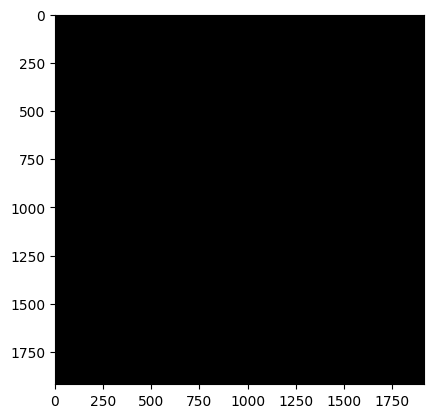

In [9]:
folder_path = "./Images_new"
img_files = ([f for f in os.listdir(folder_path) if f.endswith('.tif' or '.tiff')])
img_files.sort()
img_stack = np.array([mpimg.imread(os.path.join(folder_path, f)) for f in img_files])
# img_stack = (img_stack - np.min(img_stack)) / (np.max(img_stack) - np.min(img_stack))


# img_stack = np.load("~/Downloads/full_img_3d_stack.npy")

img_size = img_stack.shape
layer_size = img_stack[0].shape
binaries = np.zeros(img_size, dtype=np.bool)
for i in np.arange(img_size[0]):
    data = img_stack[i].reshape(-1,1)
    num_samples = np.prod(layer_size)
    num_clusters = 2
    num_dims = 1
    beta = 1
    #thresh = threshold_otsu(nlm_img[i])
    #print('thresh = {}'.format(thresh))
    new_label, energy, params = EM_calc(num_dims, num_samples, num_clusters, data, (1,layer_size[0],layer_size[1]), void_weight=1., beta = 1., verbose=False)
    if i% 50 == 0: print('{}-th layers completed'.format(i))
    binary = new_label.reshape(layer_size).astype(np.bool)

plt.imshow(binaries[0], cmap="gray")